In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

scorecard = pd.read_csv(
    "../reports/fund_scorecard.csv"
)

nav['date'] = pd.to_datetime(
    nav['date']
)

In [19]:
top5 = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
    .head(5)
)

top5_codes = (
    top5['amfi_code']
    .tolist()
)

top5_codes

[119598, 120505, 149324, 100033, 120843]

In [20]:
def monte_carlo_projection(
    df,
    fund_code,
    years=5,
    simulations=1000
):

    fund = df[
        df['amfi_code']
        ==
        fund_code
    ].copy()

    fund = fund.sort_values(
        'date'
    )

    fund['daily_return'] = (
        fund['nav']
        .pct_change()
    )

    fund = fund.dropna()

    mu = (
        fund['daily_return']
        .mean()
    )

    sigma = (
        fund['daily_return']
        .std()
    )

    current_nav = (
        fund['nav']
        .iloc[-1]
    )

    days = years * 252

    sim_matrix = np.zeros(
        (
            days,
            simulations
        )
    )

    for i in range(simulations):

        prices = [current_nav]

        for j in range(days):

            random_return = np.random.normal(
                mu,
                sigma
            )

            next_price = (
                prices[-1]
                *
                (1 + random_return)
            )

            prices.append(
                next_price
            )

        sim_matrix[:,i] = prices[1:]

    return sim_matrix

In [21]:
best_fund = top5_codes[0]

simulations = monte_carlo_projection(
    nav,
    best_fund
)

In [22]:
lower = np.percentile(
    simulations,
    5,
    axis=1
)

median = np.percentile(
    simulations,
    50,
    axis=1
)

upper = np.percentile(
    simulations,
    95,
    axis=1
)

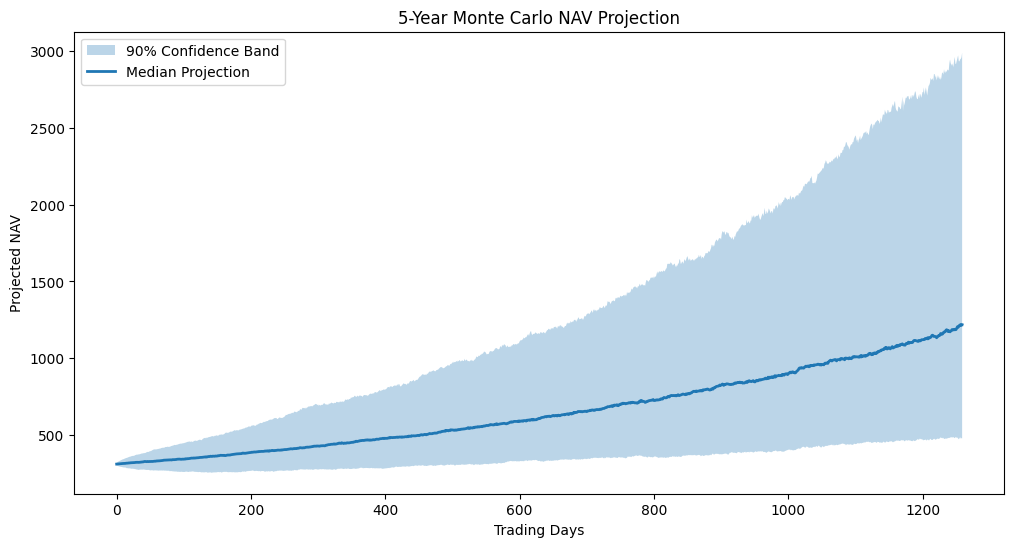

In [23]:
plt.figure(
    figsize=(12,6)
)

plt.fill_between(
    range(len(median)),
    lower,
    upper,
    alpha=0.3,
    label='90% Confidence Band'
)

plt.plot(
    median,
    linewidth=2,
    label='Median Projection'
)

plt.title(
    '5-Year Monte Carlo NAV Projection'
)

plt.xlabel(
    'Trading Days'
)

plt.ylabel(
    'Projected NAV'
)

plt.legend()
plt.savefig(
    "../reports/charts/B3_monte_carlo_projection.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [24]:
final_values = simulations[-1]

In [25]:
mc_summary = pd.DataFrame({

    'expected_nav':
        [final_values.mean()],

    'worst_case_5pct':
        [np.percentile(
            final_values,
            5
        )],

    'best_case_95pct':
        [np.percentile(
            final_values,
            95
        )]

})

mc_summary

,expected_nav,worst_case_5pct,best_case_95pct
0,1399.212631,477.198082,2989.895158


In [26]:
mc_summary.to_csv(
    "../reports/B3_monte_carlo_results.csv",
    index=False
)

In [27]:
results = []

In [28]:
for code in top5_codes:

    sim = monte_carlo_projection(
        nav,
        code
    )

    final_vals = sim[-1]

    results.append({

        'amfi_code':
            code,

        'expected_nav':
            final_vals.mean(),

        'worst_case':
            np.percentile(
                final_vals,
                5
            ),

        'best_case':
            np.percentile(
                final_vals,
                95
            )

    })

In [29]:
comparison = pd.DataFrame(
    results
)

comparison

,amfi_code,expected_nav,worst_case,best_case
0,119598,1415.420256,459.761646,3071.586496
1,120505,2050.368888,897.361075,3872.034568
2,149324,1221.485050,429.017944,2530.847194
3,100033,1324.379551,650.126042,2399.689947
4,120843,630.005827,327.718336,1032.855873


In [30]:
comparison.to_csv(
    "../reports/B3_monte_carlo_top5_comparison.csv",
    index=False
)

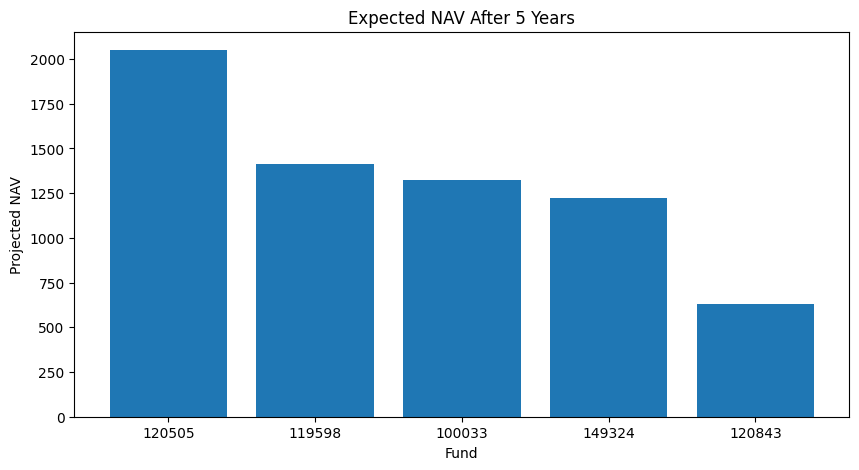

In [31]:
comparison = comparison.sort_values(
    'expected_nav',
    ascending=False
)

plt.figure(
    figsize=(10,5)
)

plt.bar(
    comparison['amfi_code'].astype(str),
    comparison['expected_nav']
)

plt.title(
    "Expected NAV After 5 Years"
)

plt.xlabel(
    "Fund"
)

plt.ylabel(
    "Projected NAV"
)
plt.savefig(
    "../reports/charts/B3_monte_carlo_top5.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Monte Carlo Simulation Findings

A Monte Carlo simulation with 1,000 iterations was used to project NAV growth over a 5-year horizon.

The simulation generated a probability distribution of future outcomes rather than a single forecast.

Results indicate that the highest-ranked funds maintain strong expected growth potential, although uncertainty bands widen substantially over longer horizons, reflecting compounding market risk.

The analysis demonstrates both upside opportunity and downside risk, providing investors with a more realistic expectation of future performance.